# 🏠 Airbnb Price Oracle
### Eden Elfassy & Léonie Chapelle
Prédiction du logarithme du prix des logements Airbnb à partir de données brutes.

## Phase 1 — Exploration des données
### Étape 1 — Chargement & inspection des données

In [3]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de l'affichage
pd.set_option('display.max_columns', None)  # Voir toutes les colonnes
pd.set_option('display.max_colwidth', 50)   # Limiter la largeur des colonnes texte
plt.style.use('seaborn-v0_8')               # Style des graphiques

In [4]:
# Chargement des données
train = pd.read_csv('../data/raw/airbnb_train.csv')
test = pd.read_csv('../data/raw/airbnb_test.csv')

print(f"Train : {train.shape[0]} lignes, {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]} lignes, {test.shape[1]} colonnes")

Train : 22234 lignes, 28 colonnes
Test  : 51877 lignes, 27 colonnes


In [5]:
# Aperçu des premières lignes
train.head(3)

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,LA,Large bright airy room with 2 balconies and Ja...,NaN,t,f,NaN,2015-12-12,t,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,NYC,Private room for rent in a six bedroom apt wit...,2017-05-07,t,t,100%,2016-11-04,t,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,DC,"14th st corridor 2br/2ba condo, secure boutiqu...",NaN,t,f,NaN,2016-12-11,t,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0


In [6]:
# Vue d'ensemble : types de données et valeurs manquantes
missing = pd.DataFrame({
    'Type'     : train.dtypes,
    'Manquants': train.isnull().sum(),
    '% manquants': (train.isnull().sum() / len(train) * 100).round(1)
})

print(missing[missing['Manquants'] > 0].sort_values('% manquants', ascending=False))

                           Type  Manquants  % manquants
host_response_rate       object       5475         24.6
review_scores_rating    float64       4978         22.4
first_review             object       4725         21.3
last_review              object       4716         21.2
neighbourhood            object       2086          9.4
zipcode                  object        303          1.4
host_has_profile_pic     object         56          0.3
host_identity_verified   object         56          0.3
host_since               object         56          0.3
bathrooms               float64         51          0.2
beds                    float64         35          0.2
bedrooms                float64         26          0.1


In [7]:
# Statistiques descriptives des variables numériques
train.describe().round(2)

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,22234.00,22234.00,22234.00,22183.00,22234.00,22234.00,22234.00,17256.00,22208.00,22199.00
mean,11222692.18,4.78,3.16,1.24,38.46,-92.27,20.67,94.07,1.26,1.71
std,6080480.28,0.72,2.14,0.59,3.07,21.67,37.18,7.78,0.85,1.25
min,3362.00,2.30,1.00,0.00,33.34,-122.51,0.00,20.00,0.00,0.00
25%,6202924.25,4.32,2.00,1.00,34.14,-118.34,1.00,92.00,1.00,1.00
50%,12174250.00,4.70,2.00,1.00,40.66,-76.99,6.00,96.00,1.00,1.00
75%,16395021.50,5.22,4.00,1.00,40.75,-73.95,23.00,100.00,1.00,2.00
max,21204503.00,7.60,16.00,8.00,42.39,-70.99,505.00,100.00,10.00,18.00


### 📋 Observations étape 1

- **22 234 lignes** dans le train set
- **4 colonnes avec beaucoup de valeurs manquantes** : 
  `host_response_rate` (24.6%), `review_scores_rating` (22.4%), 
  `first_review` (21.3%), `last_review` (21.2%)
- `host_response_rate` est stocké comme string ("100%") alors que c'est un nombre → à convertir
- `bathrooms`, `beds`, `bedrooms` ont moins de 0.2% de manquants → faciles à imputer
- `log_price` varie entre 2.30 et 7.60 → prix réels entre ~10€ et ~2000€
- `number_of_reviews` très asymétrique : médiane à 6 mais max à 505

### Étape 2 — Analyse des variables
On catégorise chaque colonne pour identifier comment la traiter dans les étapes suivantes.

In [8]:
# Catégorisation des variables
numeriques = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 
              'number_of_reviews', 'review_scores_rating',
              'latitude', 'longitude']

categorielles_nominales = ['room_type', 'property_type', 
                           'city', 'bed_type']

categorielles_ordinales = ['cancellation_policy']

booleennes = ['cleaning_fee', 'instant_bookable', 
              'host_has_profile_pic', 'host_identity_verified']

dates = ['first_review', 'last_review', 'host_since']

texte_libre = ['amenities', 'description', 'name', 'neighbourhood']

cible = ['log_price']

# Affichage propre
categories = {
    'Numériques'             : numeriques,
    'Catégorielles nominales': categorielles_nominales,
    'Catégorielles ordinales': categorielles_ordinales,
    'Booléennes'             : booleennes,
    'Dates'                  : dates,
    'Texte libre'            : texte_libre,
    'Cible'                  : cible
}

for cat, cols in categories.items():
    print(f"\n{cat} ({len(cols)}) :")
    for col in cols:
        print(f"   → {col}")


Numériques (8) :
   → accommodates
   → bathrooms
   → bedrooms
   → beds
   → number_of_reviews
   → review_scores_rating
   → latitude
   → longitude

Catégorielles nominales (4) :
   → room_type
   → property_type
   → city
   → bed_type

Catégorielles ordinales (1) :
   → cancellation_policy

Booléennes (4) :
   → cleaning_fee
   → instant_bookable
   → host_has_profile_pic
   → host_identity_verified

Dates (3) :
   → first_review
   → last_review
   → host_since

Texte libre (4) :
   → amenities
   → description
   → name
   → neighbourhood

Cible (1) :
   → log_price


In [9]:
# Vérification des valeurs uniques pour les variables catégorielles
for col in categorielles_nominales + categorielles_ordinales:
    print(f"\n{col} ({train[col].nunique()} valeurs uniques) :")
    print(train[col].value_counts().head(5))


room_type (3 valeurs uniques) :
room_type
Entire home/apt    12348
Private room        9219
Shared room          667
Name: count, dtype: int64

property_type (31 valeurs uniques) :
property_type
Apartment      14635
House           4965
Condominium      836
Townhouse        507
Loft             381
Name: count, dtype: int64

city (6 valeurs uniques) :
city
NYC        9739
LA         6672
SF         1924
DC         1744
Chicago    1127
Name: count, dtype: int64

bed_type (5 valeurs uniques) :
bed_type
Real Bed         21622
Futon              222
Pull-out Sofa      162
Airbed             146
Couch               82
Name: count, dtype: int64

cancellation_policy (5 valeurs uniques) :
cancellation_policy
strict             9726
flexible           6754
moderate           5712
super_strict_30      37
super_strict_60       5
Name: count, dtype: int64


In [10]:
# Vérification bed_type
print(train['bed_type'].value_counts())

bed_type
Real Bed         21622
Futon              222
Pull-out Sofa      162
Airbed             146
Couch               82
Name: count, dtype: int64


### 📋 Observations étape 2

- `room_type` : 3 valeurs bien équilibrées (Entire home: 12 348, Private room: 9 219, Shared room: 667) → OHE simple

- `property_type` : 31 valeurs uniques très déséquilibrées. Apartment domine avec 14 635 occurrences, 
  suivi de House (4 965). Mais beaucoup de types apparaissent moins de 50 fois (Yurt, Treehouse, Castle...). 
  Ces types ultra-rares n'apporteront aucune information utile au modèle car ils seront quasiment 
  toujours à 0. On les regroupera tous sous un label "Other" pour ne garder que les types vraiment représentatifs.

- `city` : 6 villes, NYC (9 739) et LA (6 672) très dominantes, Boston la moins représentée → OHE simple

- `cancellation_policy` : 5 valeurs dont super_strict_30 (37 occurrences) et super_strict_60 
  (5 occurrences) sont quasi absentes. On les regroupera avec "strict" lors de l'encodage ordinal 
  (flexible=0, moderate=1, strict=2). L'ordre a un sens naturel : plus c'est strict, plus c'est contraignant.

- `amenities` : liste d'équipements brute à parser spécifiquement en phase 2

- `description` et `name` : texte libre trop complexe et trop variable d'un logement à l'autre → ignorés

### Étape 3 — Nettoyage des données

In [11]:
# On travaille sur une copie pour ne jamais modifier les données originales
train_clean = train.copy()
test_clean = test.copy()

In [12]:
# Conversion des colonnes booléennes "t"/"f" en 0/1
bool_cols = ['cleaning_fee', 'instant_bookable', 
             'host_has_profile_pic', 'host_identity_verified']

for col in bool_cols:
    train_clean[col] = train_clean[col].map({'t': 1, 'f': 0})
    test_clean[col]  = test_clean[col].map({'t': 1, 'f': 0})

print("Booléennes converties ✅")
print(train_clean[bool_cols].head(3))

Booléennes converties ✅
   cleaning_fee  instant_bookable  host_has_profile_pic  \
0           NaN                 1                   1.0   
1           NaN                 1                   1.0   
2           NaN                 1                   1.0   

   host_identity_verified  
0                     0.0  
1                     1.0  
2                     0.0  


In [13]:
# Conversion host_response_rate : "100%" → 100.0
def convert_response_rate(df):
    df['host_response_rate'] = df['host_response_rate'].str.replace('%', '').astype(float)
    median_rate = train_clean['host_response_rate'].median()
    df['host_response_rate'] = df['host_response_rate'].fillna(median_rate)
    return df

train_clean = convert_response_rate(train_clean)
test_clean  = convert_response_rate(test_clean)

print(f"host_response_rate converti ✅  (médiane = {train_clean['host_response_rate'].median()}%)")

host_response_rate converti ✅  (médiane = 100.0%)


In [14]:
# Création de has_review avant d'imputer
train_clean['has_review'] = train_clean['review_scores_rating'].notnull().astype(int)
test_clean['has_review']  = test_clean['review_scores_rating'].notnull().astype(int)

# Imputation par la médiane
median_rating = train_clean['review_scores_rating'].median()
train_clean['review_scores_rating'] = train_clean['review_scores_rating'].fillna(median_rating)
test_clean['review_scores_rating']  = test_clean['review_scores_rating'].fillna(median_rating)

print(f"has_review créé ✅")
print(f"review_scores_rating imputé avec médiane = {median_rating} ✅")

has_review créé ✅
review_scores_rating imputé avec médiane = 96.0 ✅


In [15]:
# Imputation par la médiane groupée par room_type
for col in ['bathrooms', 'bedrooms', 'beds']:
    medians = train_clean.groupby('room_type')[col].median()
    
    for room in medians.index:
        mask_train = (train_clean['room_type'] == room) & (train_clean[col].isnull())
        mask_test  = (test_clean['room_type'] == room)  & (test_clean[col].isnull())
        
        train_clean.loc[mask_train, col] = medians[room]
        test_clean.loc[mask_test, col]   = medians[room]

print("bathrooms, bedrooms, beds imputés ✅")
print(train_clean[['bathrooms', 'bedrooms', 'beds']].isnull().sum())

bathrooms, bedrooms, beds imputés ✅
bathrooms    0
bedrooms     0
beds         0
dtype: int64


In [19]:
# Vérification : plus aucune valeur manquante sur les colonnes traitées
cols_traitees = bool_cols + ['host_response_rate', 'review_scores_rating', 
                              'has_review', 'bathrooms', 'bedrooms', 'beds']

print("Valeurs manquantes après nettoyage :")
print(train_clean[cols_traitees].isnull().sum())

Valeurs manquantes après nettoyage :
cleaning_fee              0
instant_bookable          0
host_has_profile_pic      0
host_identity_verified    0
host_response_rate        0
review_scores_rating      0
has_review                0
bathrooms                 0
bedrooms                  0
beds                      0
dtype: int64


In [17]:
train_clean['cleaning_fee'] = train_clean['cleaning_fee'].fillna(0)
test_clean['cleaning_fee']  = test_clean['cleaning_fee'].fillna(0)

In [18]:
train_clean['host_has_profile_pic']    = train_clean['host_has_profile_pic'].fillna(0)
train_clean['host_identity_verified']  = train_clean['host_identity_verified'].fillna(0)
test_clean['host_has_profile_pic']     = test_clean['host_has_profile_pic'].fillna(0)
test_clean['host_identity_verified']   = test_clean['host_identity_verified'].fillna(0)

print("NaN restants corrigés ✅")

NaN restants corrigés ✅


### Étape 4 — Exploration visuelle des données (EDA)
L'objectif est de comprendre visuellement les données et de justifier 
nos choix de features pour la phase de modélisation.

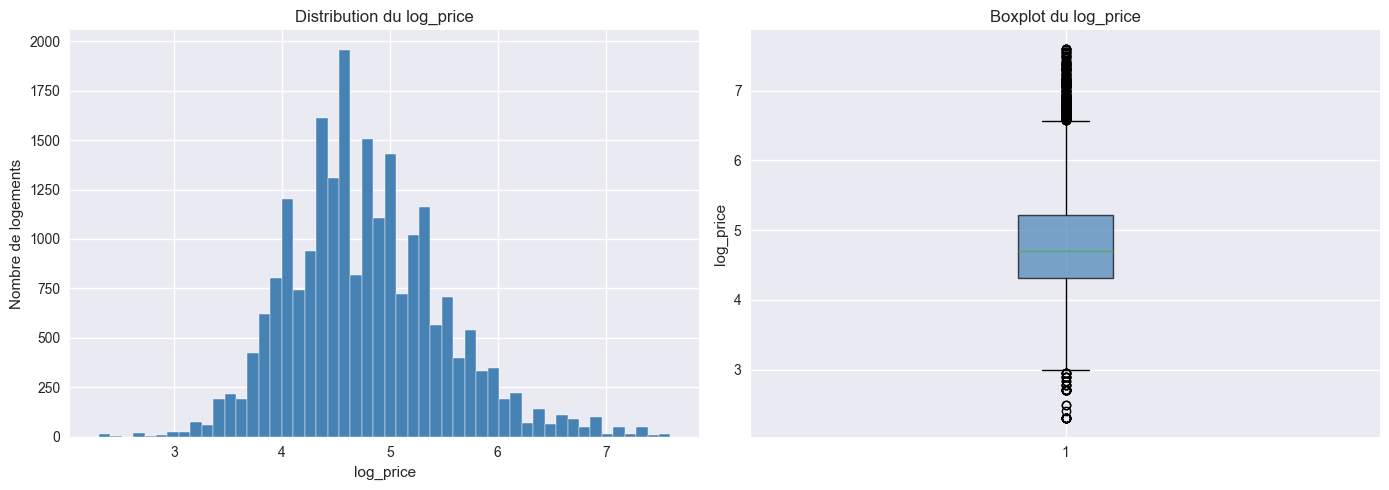

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(train_clean['log_price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du log_price')
axes[0].set_xlabel('log_price')
axes[0].set_ylabel('Nombre de logements')

# Boxplot global
axes[1].boxplot(train_clean['log_price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot du log_price')
axes[1].set_ylabel('log_price')

plt.tight_layout()
plt.savefig('../outputs/distribution_log_price.png', dpi=150, bbox_inches='tight')
plt.show()

La distribution du `log_price` est approximativement normale, centrée autour de 4.78 
(soit ~120$ en valeur réelle). Quelques valeurs extrêmes visibles au-dessus de 7.0 
correspondent à des logements de luxe.

C:\Users\elfde\AppData\Local\Temp\ipykernel_9672\2919931440.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_city, labels=cities, patch_artist=True)


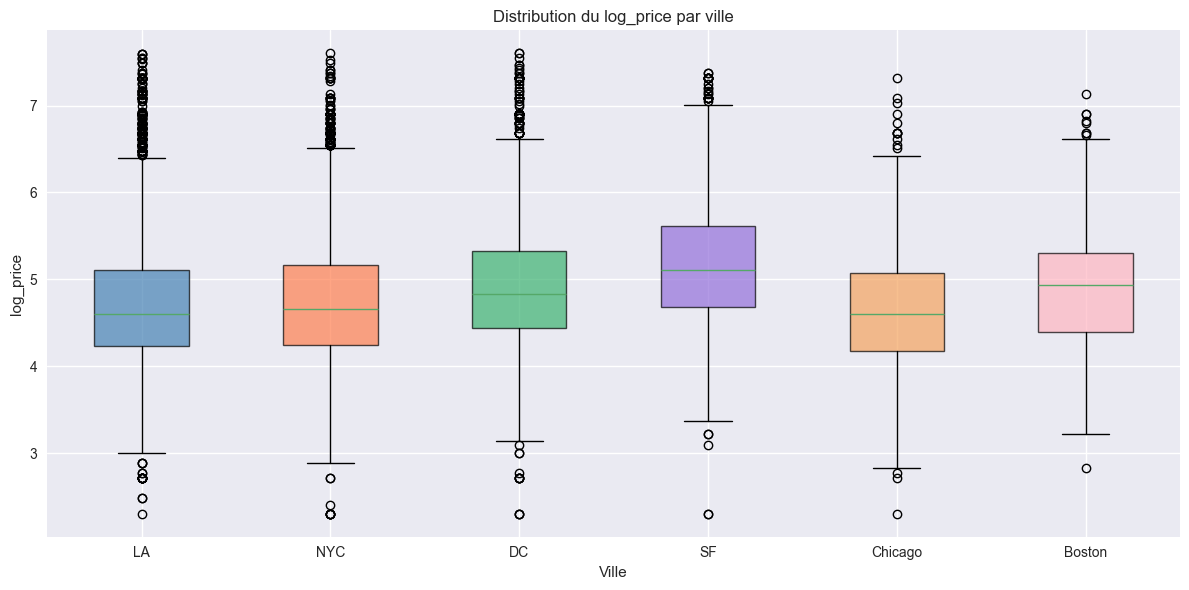

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

cities = train_clean['city'].unique()
data_by_city = [train_clean[train_clean['city'] == city]['log_price'].values 
                for city in cities]

bp = ax.boxplot(data_by_city, labels=cities, patch_artist=True)

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'sandybrown', 'lightpink']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribution du log_price par ville')
ax.set_xlabel('Ville')
ax.set_ylabel('log_price')

plt.tight_layout()
plt.savefig('../outputs/boxplot_by_city.png', dpi=150, bbox_inches='tight')
plt.show()

**SF affiche clairement les prix médians les plus élevés**, avec une boîte 
positionnée nettement au-dessus des autres villes. DC et Boston suivent de près, 
tandis que NYC — malgré sa réputation — affiche une médiane plus basse que SF, DC 
et Boston. LA et Chicago ont les prix médians les plus modérés.

On note également que LA a beaucoup plus d'outliers vers le haut (logements de luxe) 
que les autres villes, ce qui s'explique par la présence de villas et maisons haut 
de gamme typiques de Los Angeles.

La variable `city` est donc **très discriminante** pour la prédiction du prix 
et sera une feature essentielle dans nos modèles.

C:\Users\elfde\AppData\Local\Temp\ipykernel_9672\1114233493.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_room, labels=room_types, patch_artist=True)


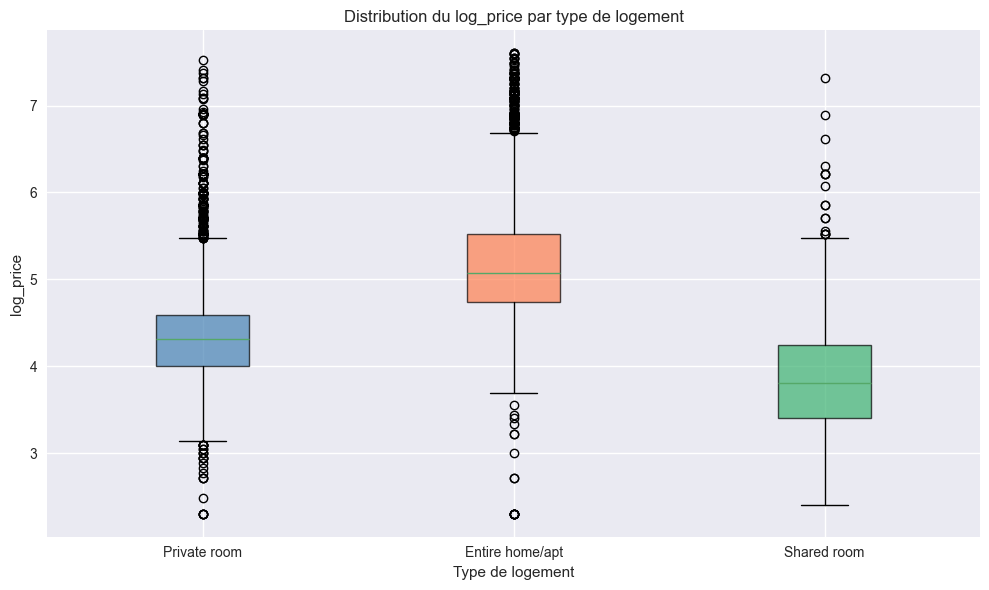

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

room_types = train_clean['room_type'].unique()
data_by_room = [train_clean[train_clean['room_type'] == rt]['log_price'].values 
                for rt in room_types]

bp = ax.boxplot(data_by_room, labels=room_types, patch_artist=True)

colors = ['steelblue', 'coral', 'mediumseagreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribution du log_price par type de logement')
ax.set_xlabel('Type de logement')
ax.set_ylabel('log_price')

plt.tight_layout()
plt.savefig('../outputs/boxplot_by_roomtype.png', dpi=150, bbox_inches='tight')
plt.show()

Le graphique confirme une hiérarchie très claire entre les 3 types de logements :

- `Entire home/apt` : médiane autour de 5.1 (~165$) — le plus cher logiquement 
  car on loue tout le logement
- `Private room` : médiane autour de 4.3 (~74$) — on partage les espaces communs
- `Shared room` : médiane autour de 3.9 (~49$) — le moins cher, on partage la chambre

Un point intéressant : `Private room` a énormément d'outliers vers le haut (jusqu'à 7.5) 
ce qui suggère que certaines chambres privées dans des logements de luxe peuvent 
atteindre des prix très élevés.

Cette hiérarchie très nette confirme que `room_type` sera l'une des variables 
les plus importantes de notre modèle.

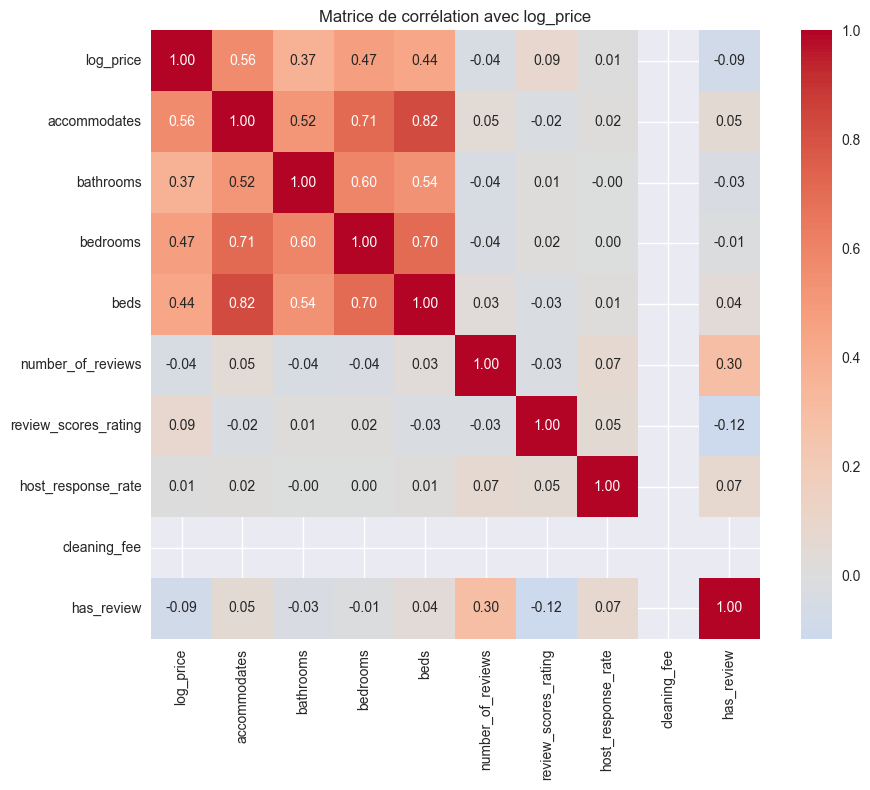

In [23]:
cols_corr = ['log_price', 'accommodates', 'bathrooms', 'bedrooms', 
             'beds', 'number_of_reviews', 'review_scores_rating',
             'host_response_rate', 'cleaning_fee', 'has_review']

corr_matrix = train_clean[cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True)
ax.set_title('Matrice de corrélation avec log_price')

plt.tight_layout()
plt.savefig('../outputs/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Lecture de la matrice de corrélation

La première ligne/colonne `log_price` nous donne les corrélations 
avec le prix — c'est ce qui nous intéresse le plus :

**Corrélations positives fortes avec log_price :**
- `accommodates` : 0.56 — plus le logement accueille de personnes, plus il est cher
- `bedrooms` : 0.47 — plus il y a de chambres, plus c'est cher
- `bathrooms` : 0.37 — même logique
- `beds` : 0.44 — cohérent avec accommodates

Ces 4 variables mesurent toutes la **taille du logement** et sont 
fortement liées entre elles (ex: accommodates/beds = 0.82).

**Corrélations faibles ou nulles :**
- `number_of_reviews` : -0.04 — quasi nul, le nombre d'avis n'influence pas le prix
- `review_scores_rating` : 0.09 — la note non plus, surprenant mais cohérent
- `host_response_rate` : 0.01 — aucun lien avec le prix
- `cleaning_fee` : données manquantes, à investiguer

**Conclusion :** Les variables de taille du logement (`accommodates`, 
`bedrooms`, `bathrooms`, `beds`) sont les plus corrélées au prix parmi 
les variables numériques. Les variables liées aux avis et à l'hôte 
ont peu d'impact direct sur le prix.

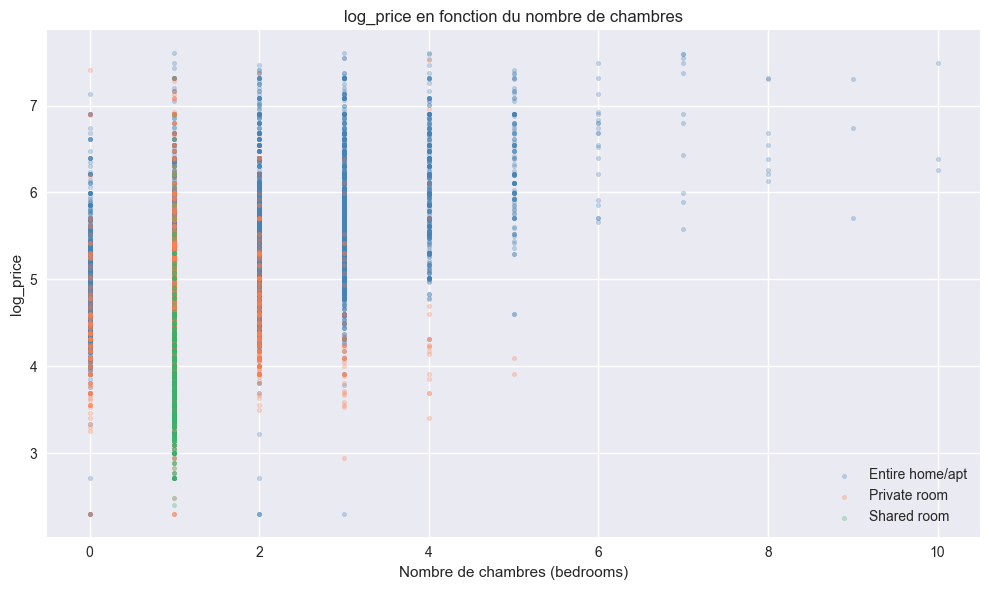

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

for rt, color in zip(['Entire home/apt', 'Private room', 'Shared room'], 
                     ['steelblue', 'coral', 'mediumseagreen']):
    subset = train_clean[train_clean['room_type'] == rt]
    ax.scatter(subset['bedrooms'], subset['log_price'], 
               alpha=0.3, color=color, label=rt, s=10)

ax.set_title('log_price en fonction du nombre de chambres')
ax.set_xlabel('Nombre de chambres (bedrooms)')
ax.set_ylabel('log_price')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/scatter_bedrooms.png', dpi=150, bbox_inches='tight')
plt.show()

### Lecture du scatter bedrooms vs log_price

On observe une tendance claire : **plus il y a de chambres, plus le prix monte**.

**Points clés :**
- La majorité des logements ont 0, 1 ou 2 chambres (colonnes très denses à gauche)
- Les logements `Entire home/apt` (bleu) dominent à partir de 2 chambres et 
  atteignent les prix les plus élevés
- Les `Private room` (orange) se concentrent sur 0-1 chambre avec des prix plus bas
- Les `Shared room` (vert) sont quasi exclusivement à 0-1 chambre, prix les plus bas
- Au-delà de 5 chambres les points se raréfient — ce sont des logements atypiques 
  (grandes villas, maisons familiales)

**Conclusion :** `bedrooms` est une feature utile mais son effet sur le prix 
est fortement lié au `room_type` — les deux variables interagissent ensemble, 
ce qu'on exploitera en phase 2 avec nos ratios.

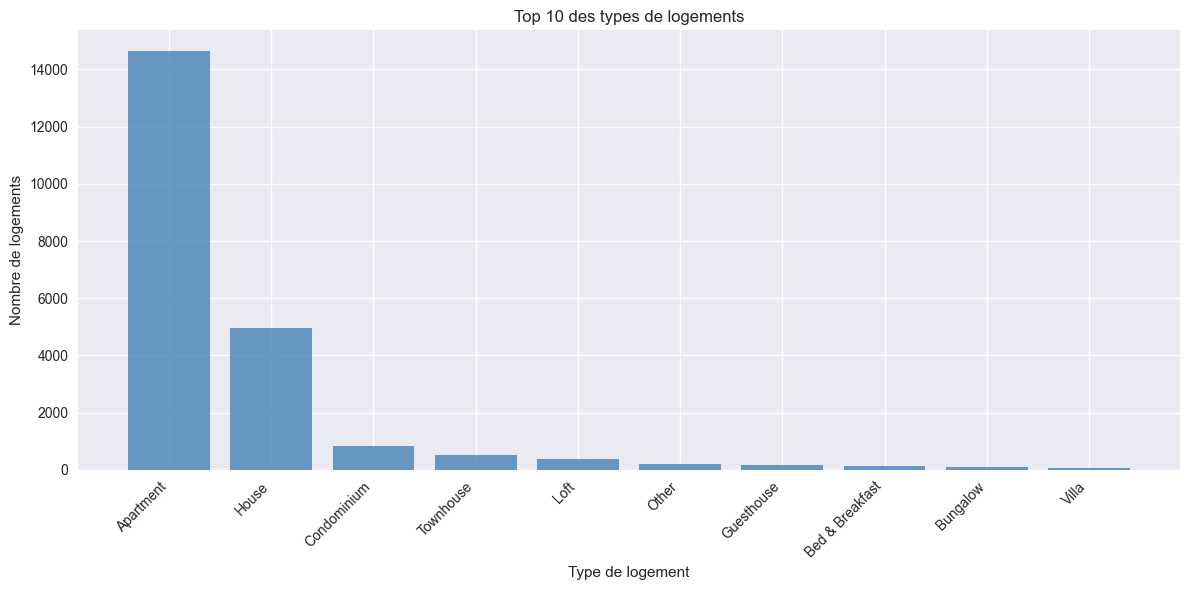

In [25]:
# On garde les 10 types les plus fréquents
top_types = train_clean['property_type'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top_types.index, top_types.values, color='steelblue', alpha=0.8)

ax.set_title('Top 10 des types de logements')
ax.set_xlabel('Type de logement')
ax.set_ylabel('Nombre de logements')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../outputs/property_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Lecture du bar chart property_type

Le déséquilibre est frappant : `Apartment` domine massivement avec ~14 600 
logements, soit presque **3x plus** que le deuxième type (`House` ~5 000).

À partir de `Guesthouse`, les barres deviennent quasi invisibles — ces types 
ont moins de 200 occurrences chacun sur 22 000 logements.

**Conséquence pour la phase 2 :** On gardera uniquement les 5 types 
bien représentés (Apartment, House, Condominium, Townhouse, Loft) et on 
regroupera tout le reste en "Other". Cela évitera de créer des colonnes 
quasi vides qui pollueraient le modèle.

### 📋 Bilan Phase 1 — Exploration

Les variables les plus prometteuses identifiées lors de l'EDA :
- `city` : forte variation des prix selon la ville (SF > DC > Boston > NYC > Chicago > LA)
- `room_type` : hiérarchie très claire (Entire > Private > Shared)
- `accommodates`, `bedrooms`, `bathrooms`, `beds` : corrélés positivement au prix (taille du logement)
- `property_type` : à encoder après regroupement — garder top 5 + "Other"
- `cleaning_fee` : à investiguer en phase 2

Ces observations guideront nos choix de features en Phase 2.